In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('hotel_bookings.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
df.shape

(119390, 32)

In [8]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
company,94.306893
agent,13.686238
country,0.408744
children,0.003350
arrival_date_month,0.000000
arrival_date_week_number,0.000000
hotel,0.000000
is_canceled,0.000000
stays_in_weekend_nights,0.000000
arrival_date_day_of_month,0.000000


In [9]:
df.drop('company', axis=1, inplace=True)

In [10]:
df['agent']=df['agent'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [12]:
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,Unknown,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [13]:
df['hotel'].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [14]:
hotel_cancelled = (
    df.groupby('hotel')['is_canceled']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)



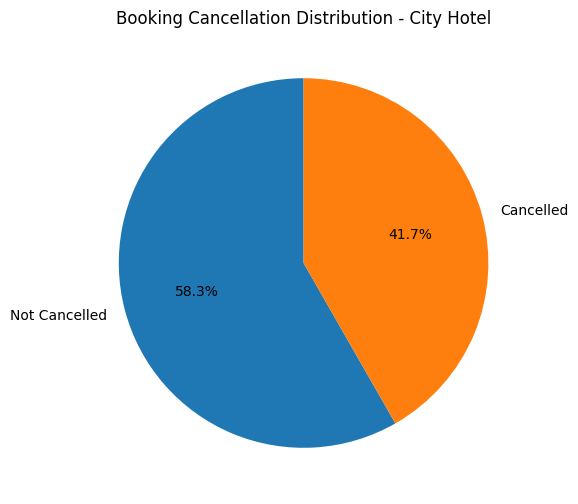

In [15]:
city = hotel_cancelled[hotel_cancelled['hotel'] == 'City Hotel']

plt.figure(figsize=(6,6))
plt.pie(
    city['Percentage'],
    labels=['Not Cancelled', 'Cancelled'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Booking Cancellation Distribution - City Hotel')
plt.show()

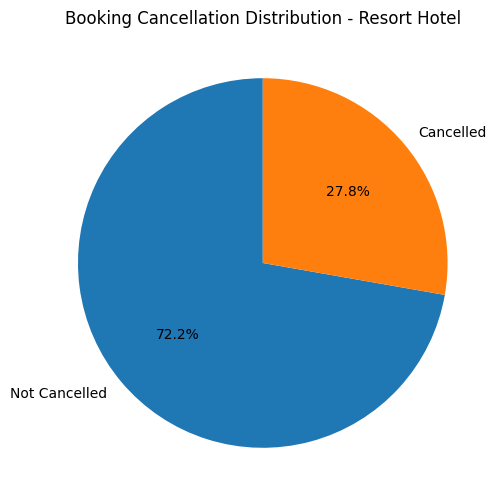

In [16]:
resort = hotel_cancelled[hotel_cancelled['hotel'] == 'Resort Hotel']

plt.figure(figsize=(6,6))
plt.pie(
    resort['Percentage'],
    labels=['Not Cancelled', 'Cancelled'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Booking Cancellation Distribution - Resort Hotel')
plt.show()

In [18]:
city_df = df[df['hotel'] == 'City Hotel']

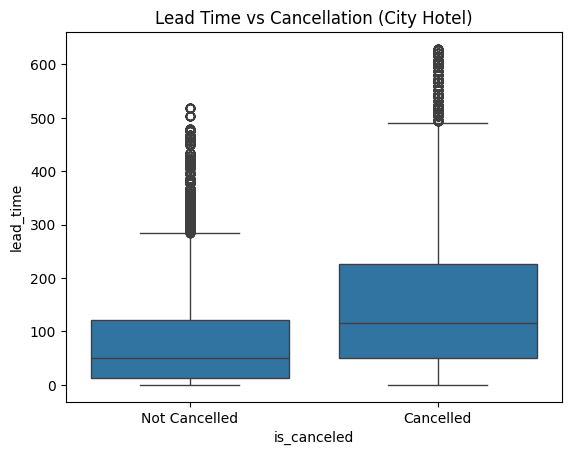

In [19]:
sns.boxplot(data=city_df, x='is_canceled', y='lead_time')
plt.xticks([0,1], ['Not Cancelled', 'Cancelled'])
plt.title('Lead Time vs Cancellation (City Hotel)')
plt.show()

In [20]:
deposit = (
    city_df.groupby('deposit_type')['is_canceled']
           .value_counts(normalize=True)
           .mul(100)
           .rename('Percentage')
           .reset_index()
)

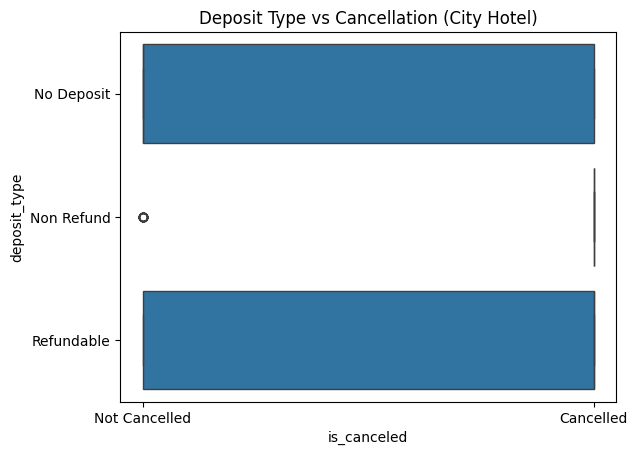

In [23]:
sns.boxplot(data=city_df, x='is_canceled', y='deposit_type')
plt.xticks([0,1], ['Not Cancelled', 'Cancelled'])
plt.title('Deposit Type vs Cancellation (City Hotel)')
plt.show()

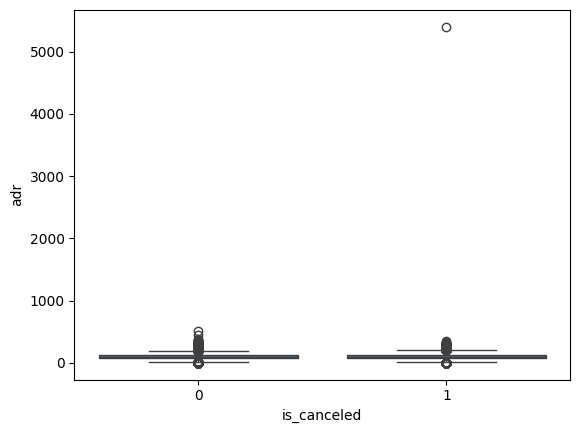

In [25]:
sns.boxplot(data=city_df,
            x='is_canceled',
            y='adr')
plt.show()

In [26]:
df.groupby(['hotel', 'customer_type'])['is_canceled'] \
  .value_counts(normalize=True) \
  .mul(100)

hotel         customer_type    is_canceled
City Hotel    Contract         0              51.956522
                               1              48.043478
              Group            0              90.102389
                               1               9.897611
              Transient        0              54.383543
                               1              45.616457
              Transient-Party  0              71.903306
                               1              28.096694
Resort Hotel  Contract         0              91.159910
                               1               8.840090
              Group            0              89.436620
                               1              10.563380
              Transient        0              68.830481
                               1              31.169519
              Transient-Party  0              80.503145
                               1              19.496855
Name: proportion, dtype: float64

## 📊 Customer Type vs Booking Cancellation

### Observation

- Contract customers in **City Hotels** recorded the highest cancellation rate (**48.0%**).
- Transient customers in **City Hotels** also showed a high cancellation rate (**45.6%**).
- Group bookings had the lowest cancellation rates in both hotel types (around **10%**).
- Resort Hotels experienced lower cancellation rates across most customer types.

### Business Insight

These findings suggest that individual and contract-based bookings are more likely to be cancelled, while group bookings are comparatively more reliable. Hotels may consider implementing flexible booking policies or targeted confirmation strategies for customer segments with higher cancellation rates.

In [28]:
df['arrival_date_year'].unique()

array([2015, 2016, 2017])

In [39]:
monthly_rate = (
    df.groupby(['hotel', 'arrival_date_month'])['is_canceled']
      .mean()
      .mul(100)
      .reset_index(name='Cancellation Rate')
)

In [40]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_rate['arrival_date_month'] = pd.Categorical(
    monthly_rate['arrival_date_month'],
    categories=month_order,
    ordered=True
)

monthly_rate = monthly_rate.sort_values('arrival_date_month')

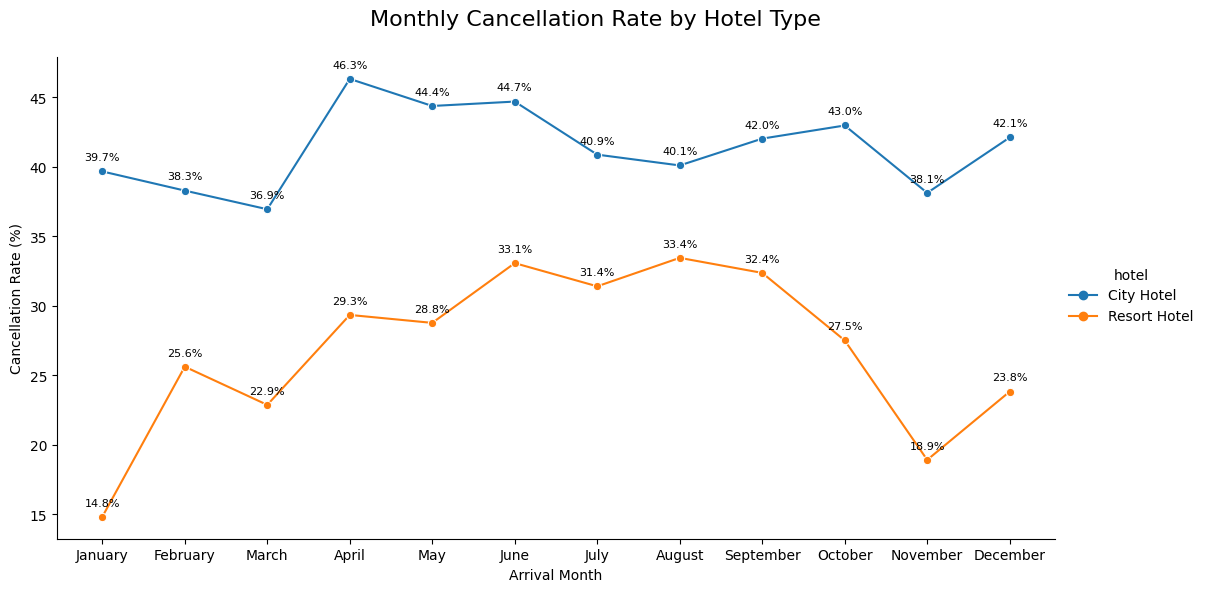

In [42]:
g = sns.relplot(
    data=monthly_rate,
    x='arrival_date_month',
    y='Cancellation Rate',
    hue='hotel',
    kind='line',
    marker='o',
    height=6,
    aspect=1.8
)
g.fig.suptitle("Monthly Cancellation Rate by Hotel Type", fontsize=16)
g.fig.subplots_adjust(top=0.9)
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Arrival Month')
for ax in g.axes.flat:
    for line in ax.lines:
        for x, y in zip(line.get_xdata(), line.get_ydata()):
            ax.text(x, y + 0.8, f'{y:.1f}%', fontsize=8, ha='center')
plt.show()

## Monthly Cancellation Rate by Hotel Type

### Observation

- City Hotels consistently recorded higher cancellation rates than Resort Hotels throughout the year.
- The highest cancellation rate for City Hotels occurred in **April** (approximately 46%).
- Resort Hotels experienced their highest cancellation rates during the summer months (June–August).
- Both hotel types showed lower cancellation rates in November.

### Business Insight

The findings indicate that City Hotels are more susceptible to booking cancellations regardless of the season. Resort Hotels exhibit stronger seasonal variation, with cancellations increasing during peak travel months. Hotels can use these trends to strengthen confirmation strategies and optimize overbooking policies during periods with historically high cancellation rates.

In [43]:
df['total_of_special_requests'].unique()

array([0, 1, 3, 2, 4, 5])

In [44]:
request_cancelled = (
    df.groupby('total_of_special_requests')['is_canceled']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

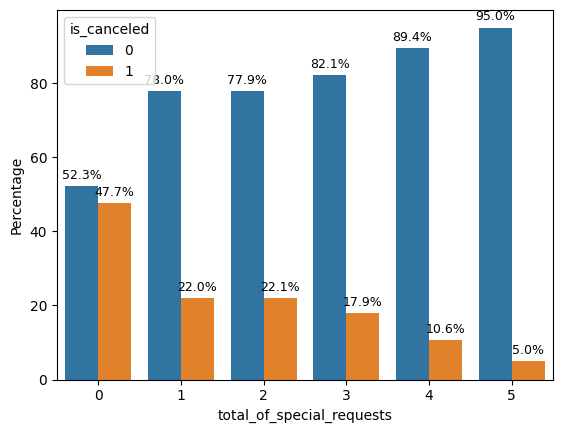

In [47]:
ax = sns.barplot(
    data=request_cancelled,
    x='total_of_special_requests',
    y='Percentage',
    hue='is_canceled'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

plt.show()

## Total Special Requests vs Booking Cancellation

### Observation

- Bookings with **0 special requests** recorded the highest cancellation rate (approximately 48%).
- As the number of special requests increased, the cancellation rate steadily decreased.
- Bookings with **4–5 special requests** showed the lowest cancellation rates (around 6–10%).

### Business Insight

The number of special requests appears to be negatively associated with booking cancellations. Guests who make multiple special requests are likely more committed to their travel plans, making them less likely to cancel. Hotels can use this information to improve cancellation prediction models and optimize overbooking strategies.

In [48]:
df['country'].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', 'Unknown', 'ROU', 'NOR',
       'OMN', 'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA',
       'NLD', 'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN',
       'MOZ', 'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR',
       'UKR', 'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU',
       'TUR', 'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA',
       'KOR', 'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN',
       'GEO', 'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY',
       'KWT', 'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN',
       'LBN', 'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM',
       'MKD', 'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS',
       'COM', 'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI',
       'SAU', 'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU',
       'MDG', 'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI',
       'STP', 'KN

In [60]:
top10_bookings = (
    df['country']
    .value_counts()
    .head(10)
    .reset_index()
)

top10_bookings.columns = ['country', 'Total_Bookings']

top10_bookings

,country,Total_Bookings
0,PRT,48590
1,GBR,12129
2,FRA,10415
3,ESP,8568
4,DEU,7287
5,ITA,3766
6,IRL,3375
7,BEL,2342
8,BRA,2224
9,NLD,2104


In [61]:
cancel_rate = (
    df.groupby('country')['is_canceled']
      .mean()
      .mul(100)
      .reset_index(name='Cancellation Rate')
)

top10_country = top10_bookings.merge(cancel_rate, on='country')

top10_country

,country,Total_Bookings,Cancellation Rate
0,PRT,48590,56.635110
1,GBR,12129,20.224256
2,FRA,10415,18.569371
3,ESP,8568,25.408497
4,DEU,7287,16.714697
5,ITA,3766,35.395645
6,IRL,3375,24.651852
7,BEL,2342,20.239112
8,BRA,2224,37.320144
9,NLD,2104,18.393536


/tmp/ipykernel_760/2564725542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


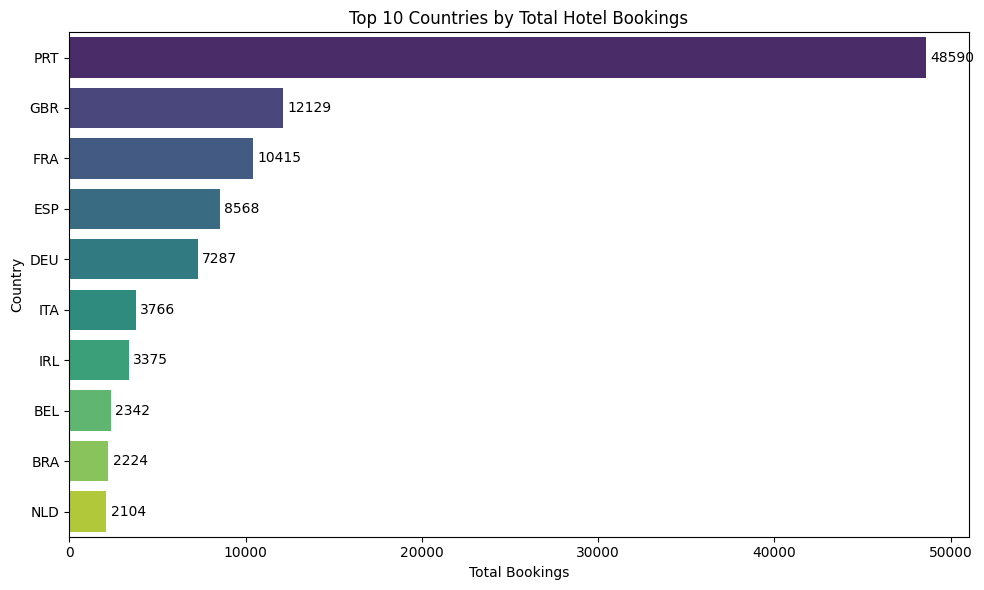

In [62]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top10_country,
    x='Total_Bookings',
    y='country',
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Top 10 Countries by Total Hotel Bookings')
plt.xlabel('Total Bookings')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

## Top 10 Countries by Hotel Bookings

### Observation

- Portugal (PRT) contributed the highest number of hotel bookings.
- The remaining top booking countries included the United Kingdom (GBR), France (FRA), Spain (ESP), and Germany (DEU).
- Although Portugal generated the largest booking volume, it also exhibited a relatively high cancellation rate compared with several other major markets.

### Business Insight

The majority of bookings originate from a small number of countries. Monitoring cancellation behavior within these high-volume markets can help hotels optimize booking policies, improve demand forecasting, and design targeted customer engagement strategies.

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [65]:
segment_cancelled = (
    df.groupby('market_segment')['is_canceled']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

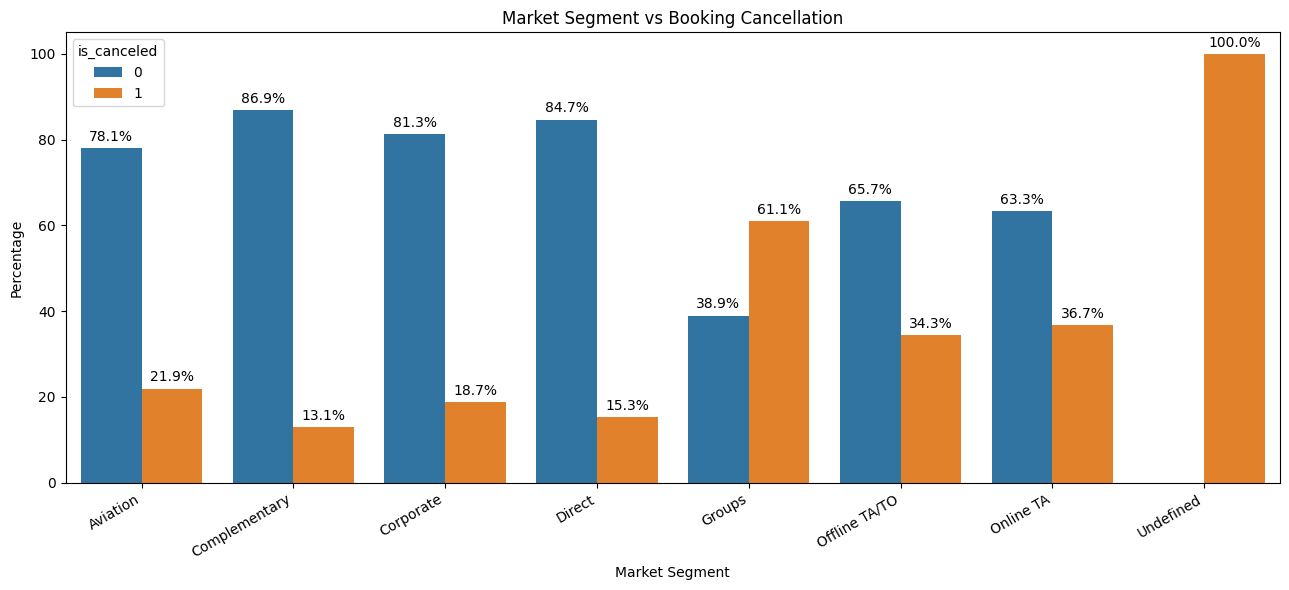

In [69]:
plt.figure(figsize=(13,6))

ax = sns.barplot(
    data=segment_cancelled,
    x='market_segment',
    y='Percentage',
    hue='is_canceled'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xticks(rotation=30, ha='right')
plt.xlabel('Market Segment')
plt.ylabel('Percentage')
plt.title('Market Segment vs Booking Cancellation')
plt.tight_layout()
plt.show()

## Market Segment vs Booking Cancellation

### Observation

- Group bookings recorded the highest cancellation rate (61.1%).
- Direct bookings had the lowest cancellation rate (15.3%).
- Corporate and Complementary bookings also showed relatively low cancellation rates.
- Online TA bookings experienced slightly higher cancellation rates than Offline TA/TO bookings.
- The Undefined category was excluded from business interpretation due to insufficient or irregular data.

### Business Insight

Booking cancellation behavior varies significantly across market segments. Direct and Corporate bookings appear to be more reliable, while Group bookings are associated with the highest cancellation risk. Hotels can use these findings to optimize booking strategies and tailor cancellation policies for different customer segments.

In [70]:
guest_cancelled = (
    df.groupby('is_repeated_guest')['is_canceled']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

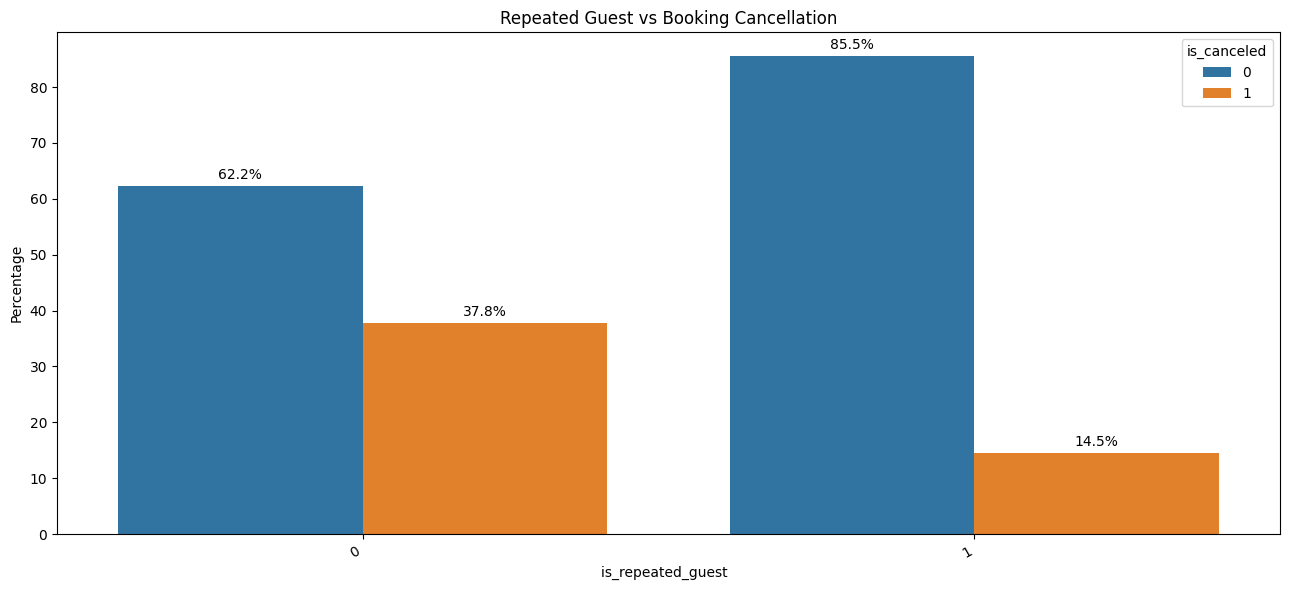

In [71]:
plt.figure(figsize=(13,6))

ax = sns.barplot(
    data=guest_cancelled,
    x='is_repeated_guest',
    y='Percentage',
    hue='is_canceled'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xticks(rotation=30, ha='right')
plt.xlabel('is_repeated_guest  ')
plt.ylabel('Percentage')
plt.title('Repeated Guest vs Booking Cancellation')
plt.tight_layout()
plt.show()

## Repeated Guest vs Booking Cancellation

### Observation

- First-time guests recorded a cancellation rate of **37.8%**.
- Repeated guests had a much lower cancellation rate of **14.5%**.
- Approximately **85.5%** of repeat guest bookings were successfully completed.

### Business Insight

Repeated guests are considerably more reliable than first-time guests. Hotels can reduce booking cancellations by strengthening customer retention strategies, such as loyalty programs, personalized discounts, and exclusive benefits for returning customers.

## Findings

1. Bookings with longer lead times were more likely to be cancelled. Cancelled reservations had a significantly higher median lead time than completed bookings.

2. City Hotels consistently recorded higher monthly cancellation rates than Resort Hotels, indicating a greater cancellation risk throughout the year.

3. Guests who made more special requests were considerably less likely to cancel their bookings, suggesting stronger booking commitment.

4. A large proportion of bookings originated from a small number of countries, highlighting key customer markets that hotels should monitor for booking trends and cancellations.

5. Booking cancellations varied across market segments. Group bookings recorded the highest cancellation rates, while Direct and Corporate bookings were the most reliable.

6. Repeated guests showed much lower cancellation rates than first-time guests, demonstrating the importance of customer loyalty in reducing booking cancellations.

## Conclusion

This exploratory data analysis identified several factors associated with hotel booking cancellations. Lead time, hotel type, market segment, special requests, customer origin, and guest loyalty all influenced cancellation behavior.

City Hotels experienced consistently higher cancellation rates than Resort Hotels, while longer lead times and group bookings were associated with increased cancellation risk. In contrast, repeated guests and customers making multiple special requests demonstrated much lower cancellation rates, indicating stronger booking commitment.

These findings can help hotel managers improve demand forecasting, optimize overbooking strategies, strengthen customer retention programs, and design targeted cancellation policies for high-risk customer segments. Overall, the analysis provides valuable business insights that can support better operational and revenue management decisions.